# Loan Default Prediction
**Banking & Financial Services · Machine Learning – Classification**

Workflow: Data → Statistics → EDA → Preprocessing → Feature Engineering → Modeling → Evaluation → Insights → Recommendations

**Business goal:** predict whether a client will default next month, identify the main risk drivers, and turn them into actions for a lender.

**Dataset:** UCI *Default of Credit Card Clients* (30,000 clients, Taiwan, 2005). Put `UCI_Credit_Card.csv` in the `data/` folder.

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
                             average_precision_score, classification_report)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
os.makedirs("../images", exist_ok=True)
def savefig(name):
    plt.tight_layout(); plt.savefig(f"../images/{name}.png", dpi=150, bbox_inches="tight")

# A. Data Understanding
| Column | Meaning |
|---|---|
| `LIMIT_BAL` | Credit limit (NT$), includes family/supplementary credit |
| `SEX` | 1 = male, 2 = female |
| `EDUCATION` | 1 = graduate school, 2 = university, 3 = high school, 4 = others |
| `MARRIAGE` | 1 = married, 2 = single, 3 = others |
| `AGE` | Age in years |
| `PAY_0 … PAY_6` | Repayment status, Sep → Apr 2005. -1 = paid duly, 0 = revolving credit (minimum paid), 1…9 = months of payment delay |
| `BILL_AMT1 … 6` | Bill statement amount, Sep → Apr |
| `PAY_AMT1 … 6` | Amount paid in the previous month, Sep → Apr |
| `default.payment.next.month` | **Target**: 1 = default, 0 = no default |

Note: in the raw file `PAY_0` is really the September status (there is no `PAY_1`). We rename it to `PAY_1` so all six months line up (`PAY_1` ↔ `BILL_AMT1` ↔ `PAY_AMT1`).

In [2]:
df = pd.read_csv("../data/UCI_Credit_Card.csv")
df = df.rename(columns={"PAY_0": "PAY_1", "default.payment.next.month": "default"})
print("Shape:", df.shape)
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_1      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 non-null  float64
 20  PAY_AMT3   30000 

In [4]:
num_cols = ["LIMIT_BAL","AGE"] + [f"BILL_AMT{i}" for i in range(1,7)] + [f"PAY_AMT{i}" for i in range(1,7)]
cat_cols = ["SEX","EDUCATION","MARRIAGE"]
pay_cols = [f"PAY_{i}" for i in range(1,7)]      # ordinal status codes
print("Numerical :", len(num_cols), "| Categorical:", cat_cols, "| Repayment status:", pay_cols)
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows (ignoring ID):", df.drop(columns="ID").duplicated().sum())
print("Duplicate IDs:", df["ID"].duplicated().sum())

Numerical : 14 | Categorical: ['SEX', 'EDUCATION', 'MARRIAGE'] | Repayment status: ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Missing values: 0
Duplicate rows (ignoring ID): 35
Duplicate IDs: 0


In [5]:
# Unique values of categorical / status columns - this is where data-quality problems hide
for c in cat_cols + pay_cols + ["default"]:
    print(f"{c:10s}", dict(sorted(df[c].value_counts().items())))

SEX        {1: 11888, 2: 18112}
EDUCATION  {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE   {0: 54, 1: 13659, 2: 15964, 3: 323}
PAY_1      {-2: 2759, -1: 5686, 0: 14737, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}
PAY_2      {-2: 3782, -1: 6050, 0: 15730, 1: 28, 2: 3927, 3: 326, 4: 99, 5: 25, 6: 12, 7: 20, 8: 1}
PAY_3      {-2: 4085, -1: 5938, 0: 15764, 1: 4, 2: 3819, 3: 240, 4: 76, 5: 21, 6: 23, 7: 27, 8: 3}
PAY_4      {-2: 4348, -1: 5687, 0: 16455, 1: 2, 2: 3159, 3: 180, 4: 69, 5: 35, 6: 5, 7: 58, 8: 2}
PAY_5      {-2: 4546, -1: 5539, 0: 16947, 2: 2626, 3: 178, 4: 84, 5: 17, 6: 4, 7: 58, 8: 1}
PAY_6      {-2: 4895, -1: 5740, 0: 16286, 2: 2766, 3: 184, 4: 49, 5: 13, 6: 19, 7: 46, 8: 2}
default    {0: 23364, 1: 6636}


**Findings so far**
- No missing values, but the categorical columns contain **undocumented codes**: `EDUCATION` ∈ {0, 5, 6} and `MARRIAGE` = 0. These are inconsistent data and are handled in preprocessing.
- `PAY_x` mixes two ideas: negatives/0 = on time or revolving, positives = delay in months. Code `-2` ("no consumption") is also undocumented.
- A small number of duplicate rows exist even though IDs are unique; they are removed.

# B. Statistical Analysis

In [6]:
desc = df[num_cols].describe().T
desc["median"]   = df[num_cols].median()
desc["mode"]     = df[num_cols].mode().iloc[0]
desc["variance"] = df[num_cols].var()
desc["IQR"]      = desc["75%"] - desc["25%"]
desc["skew"]     = df[num_cols].skew()
desc[["mean","median","mode","min","max","variance","std","25%","50%","75%","IQR","skew"]].round(2)

,mean,median,mode,min,max,variance,std,25%,50%,75%,IQR,skew
LIMIT_BAL,167484.32,140000.0,50000.0,10000.0,1000000.0,1.683446e+10,129747.66,50000.00,140000.0,240000.00,190000.00,0.99
AGE,35.49,34.0,29.0,21.0,79.0,8.497000e+01,9.22,28.00,34.0,41.00,13.00,0.73
BILL_AMT1,51223.33,22381.5,0.0,-165580.0,964511.0,5.422240e+09,73635.86,3558.75,22381.5,67091.00,63532.25,2.66
BILL_AMT2,49179.08,21200.0,0.0,-69777.0,983931.0,5.065705e+09,71173.77,2984.75,21200.0,64006.25,61021.50,2.71
BILL_AMT3,47013.15,20088.5,0.0,-157264.0,1664089.0,4.809338e+09,69349.39,2666.25,20088.5,60164.75,57498.50,3.09
BILL_AMT4,43262.95,19052.0,0.0,-170000.0,891586.0,4.138716e+09,64332.86,2326.75,19052.0,54506.00,52179.25,2.82
BILL_AMT5,40311.40,18104.5,0.0,-81334.0,927171.0,3.696294e+09,60797.16,1763.00,18104.5,50190.50,48427.50,2.88
BILL_AMT6,38871.76,17071.0,0.0,-339603.0,961664.0,3.546692e+09,59554.11,1256.00,17071.0,49198.25,47942.25,2.85
PAY_AMT1,5663.58,2100.0,0.0,0.0,873552.0,2.743423e+08,16563.28,1000.00,2100.0,5006.00,4006.00,14.67
PAY_AMT2,5921.16,2009.0,0.0,0.0,1684259.0,5.308817e+08,23040.87,833.00,2009.0,5000.00,4167.00,30.45


In [7]:
# Outlier counts using the 1.5*IQR rule
rows=[]
for c in num_cols:
    q1,q3 = df[c].quantile([.25,.75]); iqr=q3-q1
    n = ((df[c]<q1-1.5*iqr)|(df[c]>q3+1.5*iqr)).sum()
    rows.append((c, n, round(100*n/len(df),1)))
pd.DataFrame(rows, columns=["feature","n_outliers","pct"]).sort_values("pct", ascending=False)

,feature,n_outliers,pct
11,PAY_AMT4,2994,10.0
13,PAY_AMT6,2958,9.9
12,PAY_AMT5,2945,9.8
8,PAY_AMT1,2745,9.2
6,BILL_AMT5,2725,9.1
7,BILL_AMT6,2693,9.0
9,PAY_AMT2,2714,9.0
5,BILL_AMT4,2622,8.7
10,PAY_AMT3,2598,8.7
4,BILL_AMT3,2469,8.2


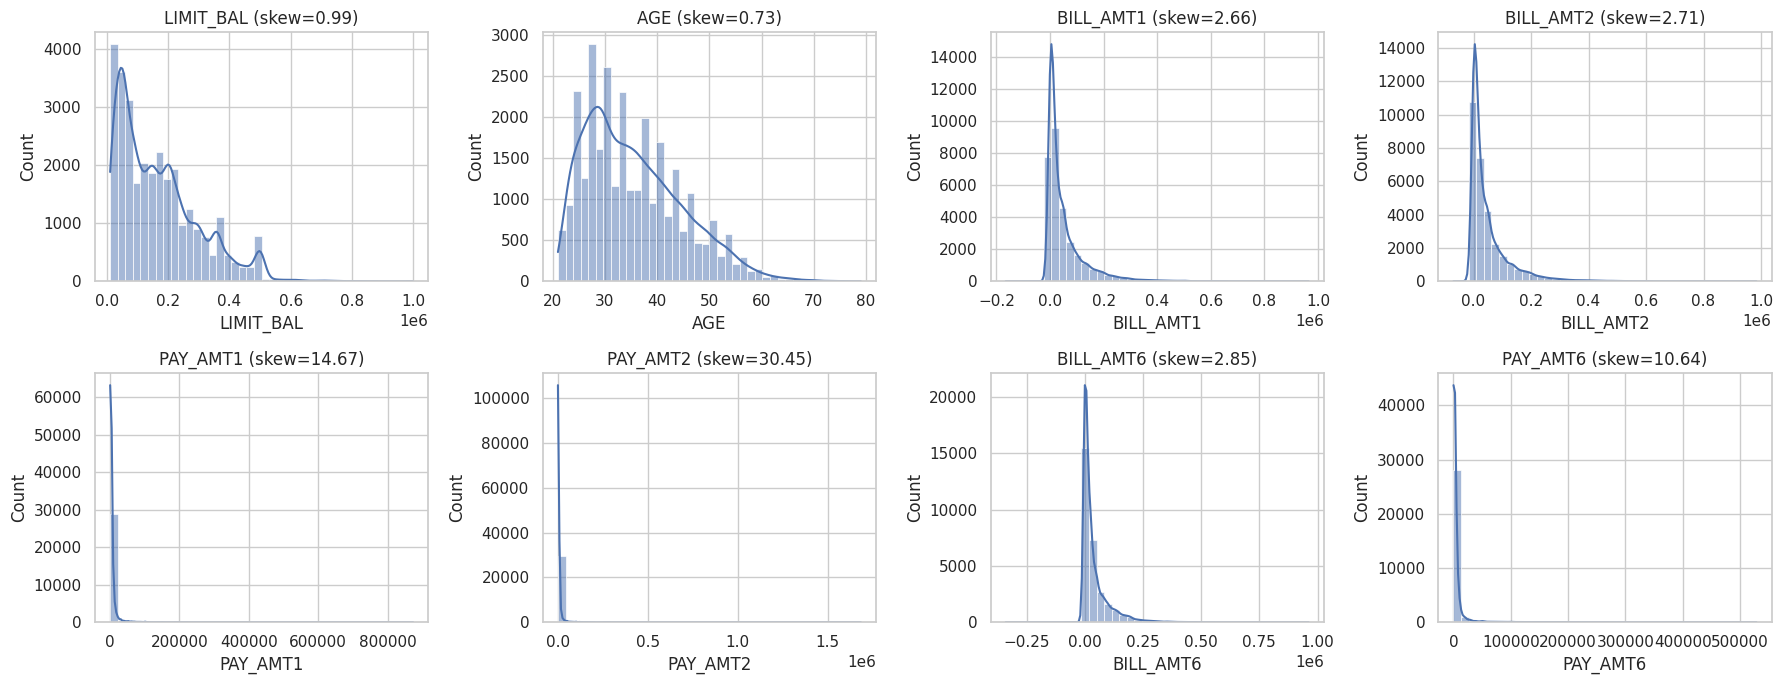

In [8]:
# Distribution analysis: skewness & normality-style summary
fig, axes = plt.subplots(2,4, figsize=(18,7))
for ax,c in zip(axes.ravel(), ["LIMIT_BAL","AGE","BILL_AMT1","BILL_AMT2","PAY_AMT1","PAY_AMT2","BILL_AMT6","PAY_AMT6"]):
    sns.histplot(df[c], kde=True, ax=ax, bins=40); ax.set_title(f"{c} (skew={df[c].skew():.2f})")
savefig("01_distributions")
plt.show()

Correlation with default:


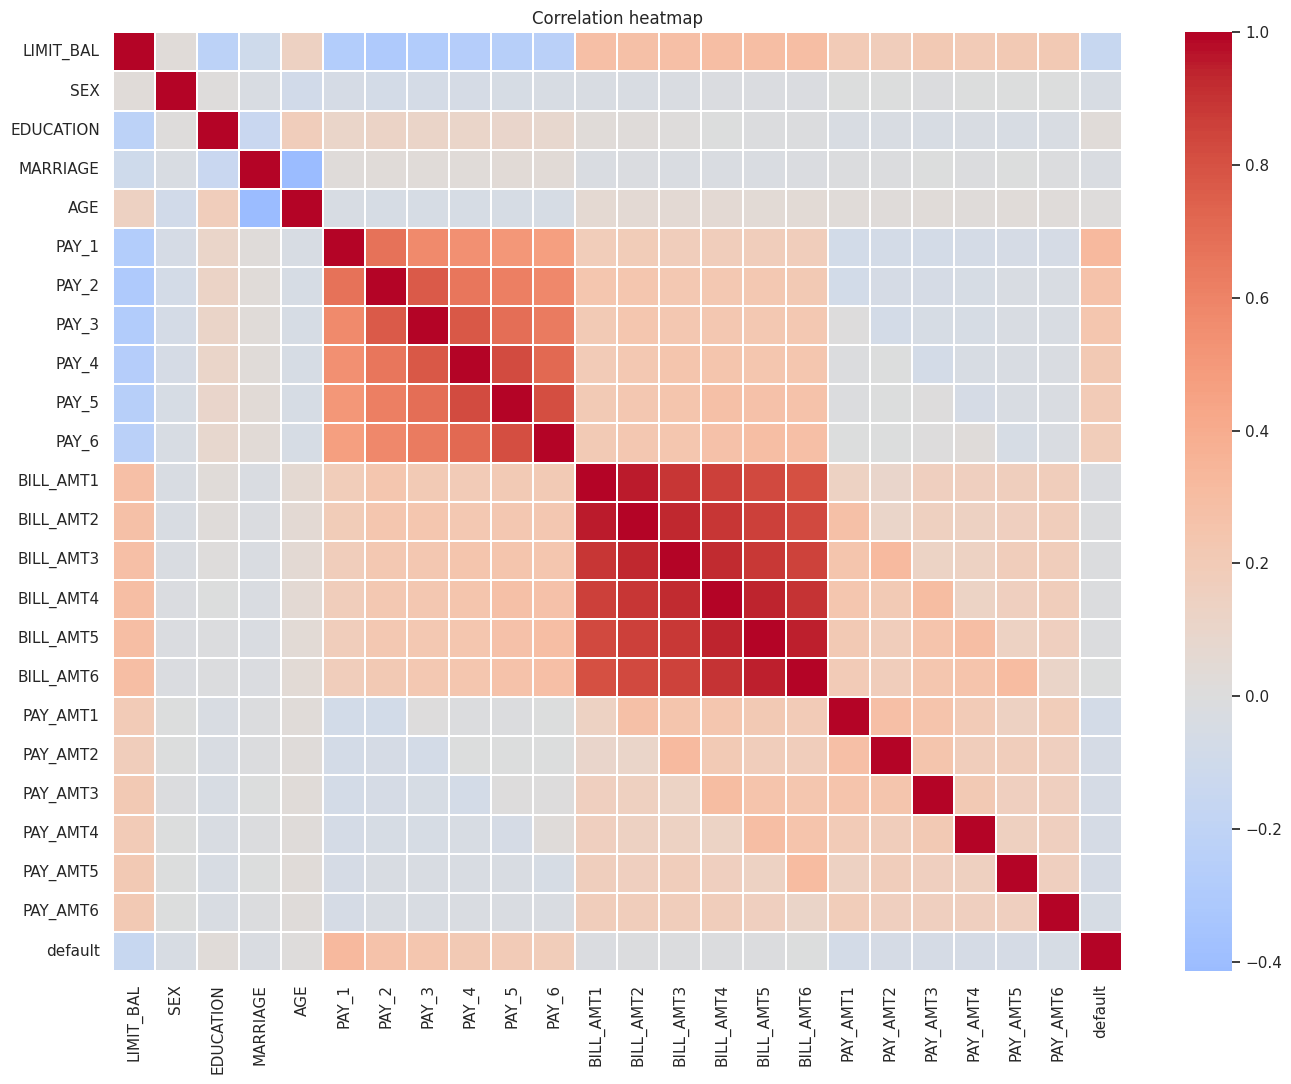

PAY_1        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
PAY_AMT3    -0.056
PAY_AMT5    -0.055
Name: default, dtype: float64

In [9]:
# Correlation analysis
corr = df.drop(columns="ID").corr()
plt.figure(figsize=(14,11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=.3)
plt.title("Correlation heatmap"); savefig("02_corr_heatmap"); plt.show()

print("Correlation with default:")
corr["default"].drop("default").sort_values(key=abs, ascending=False).round(3).head(12)

**Business reading of the statistics**
- Bill amounts and payment amounts are strongly **right-skewed** with many outliers: most clients carry modest balances, a few carry very large ones. Mean ≫ median, so the *median* is the better "typical client" figure.
- `BILL_AMT1…6` are highly correlated with each other (balances persist month to month) → redundant information / multicollinearity for linear models.
- The repayment-status columns (`PAY_1`…) have by far the strongest correlation with default: **recent payment behaviour tells more than demographics or limit**.

# C. Exploratory Data Analysis

In [10]:
# Data cleaning needed before meaningful EDA (documented, applied again in preprocessing)
df = df.drop_duplicates(subset=df.columns.drop("ID")).reset_index(drop=True)
df["EDUCATION"] = df["EDUCATION"].replace({0:4, 5:4, 6:4})   # undocumented codes -> 'others'
df["MARRIAGE"]  = df["MARRIAGE"].replace({0:3})              # undocumented code  -> 'others'
print("Shape after cleaning:", df.shape)

Shape after cleaning: (29965, 25)


### Univariate analysis

default
0    0.779
1    0.221
Name: proportion, dtype: float64


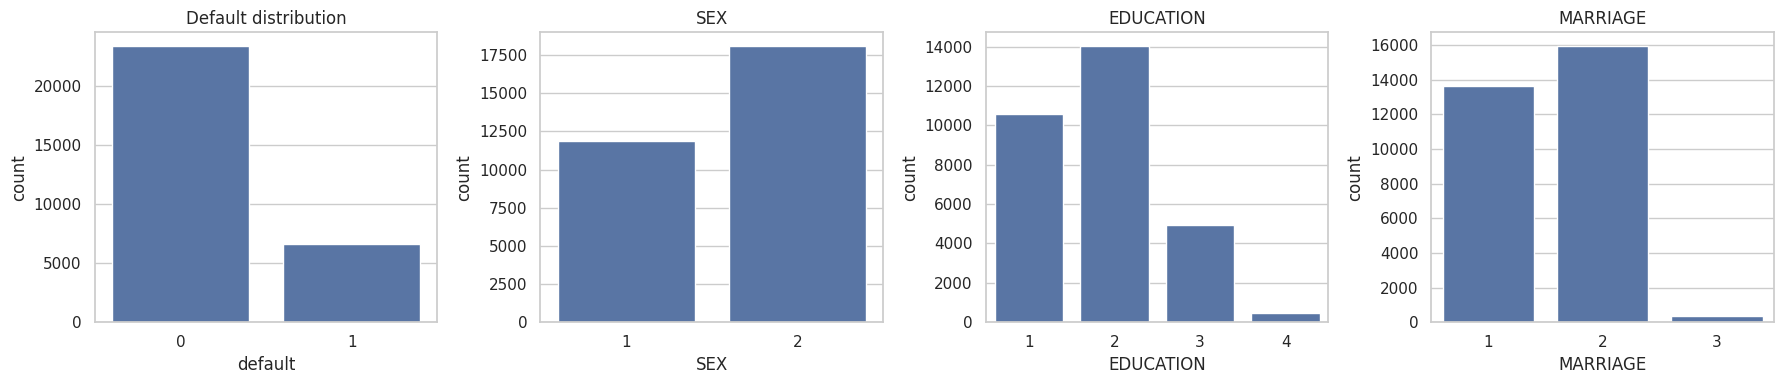

In [11]:
fig, axes = plt.subplots(1,4, figsize=(18,4))
sns.countplot(x="default", data=df, ax=axes[0]); axes[0].set_title("Default distribution")
for ax,c in zip(axes[1:], cat_cols):
    sns.countplot(x=c, data=df, ax=ax); ax.set_title(c)
savefig("03_univariate_categorical"); plt.show()
print(df["default"].value_counts(normalize=True).round(3))

**Class imbalance:** only about 22% of clients default. A model that predicts 'no default' for everyone would already be ~78% accurate yet useless, so accuracy cannot be the deciding metric.

### Bivariate analysis

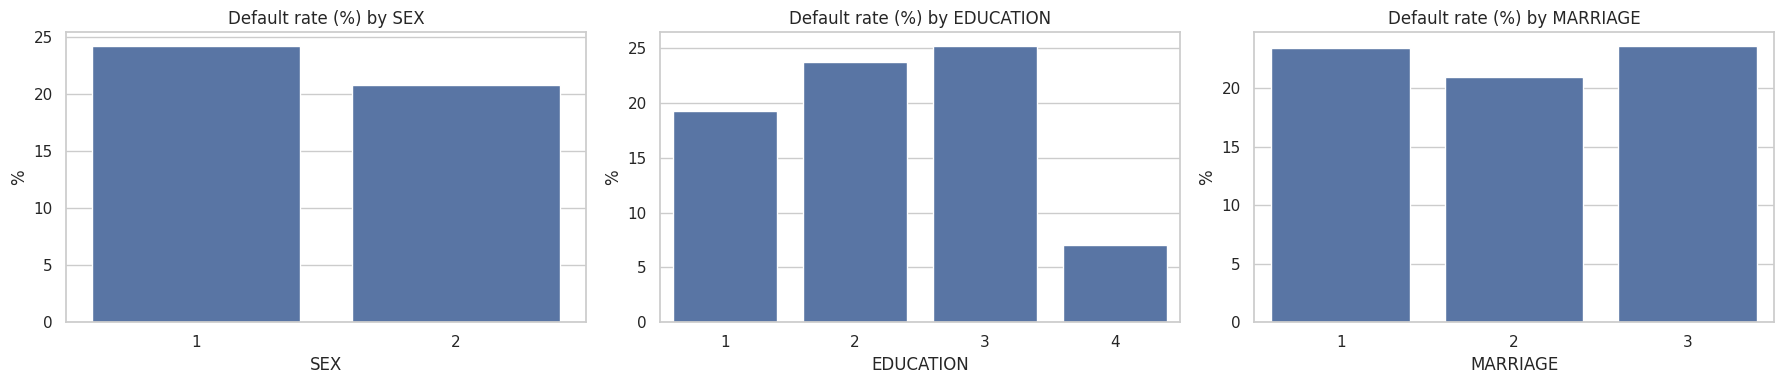

In [12]:
fig, axes = plt.subplots(1,3, figsize=(18,4))
for ax,c in zip(axes, cat_cols):
    rate = df.groupby(c)["default"].mean().mul(100)
    sns.barplot(x=rate.index, y=rate.values, ax=ax); ax.set_title(f"Default rate (%) by {c}"); ax.set_ylabel("%")
savefig("04_default_rate_by_category"); plt.show()

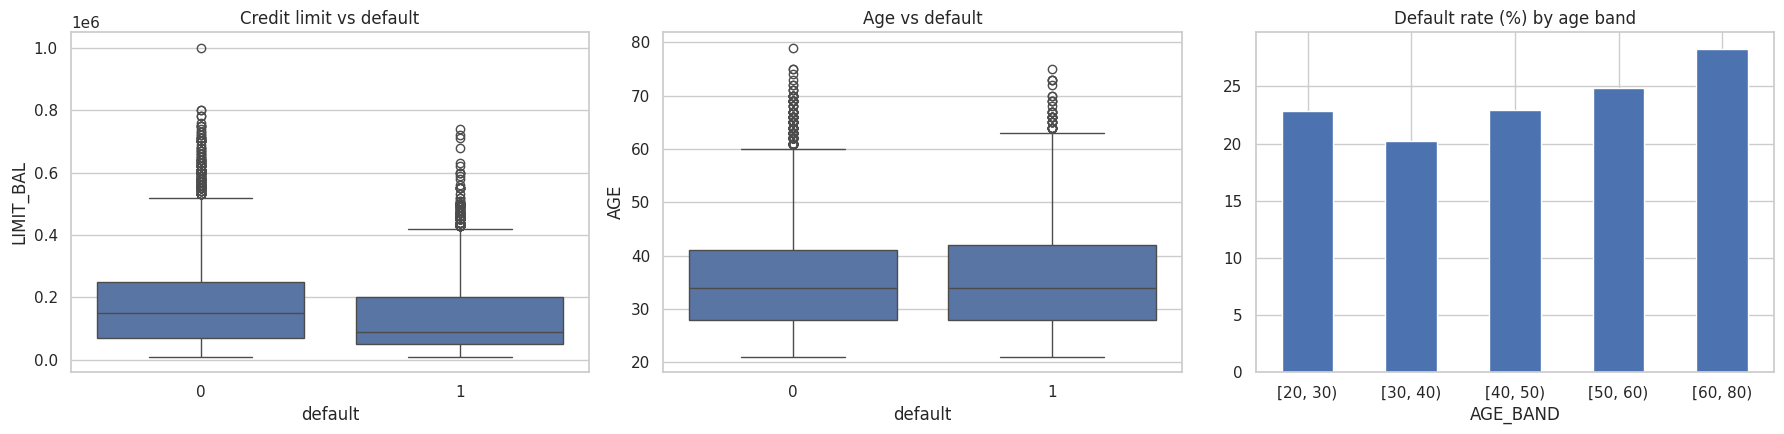

In [13]:
fig, axes = plt.subplots(1,3, figsize=(18,4.5))
sns.boxplot(x="default", y="LIMIT_BAL", data=df, ax=axes[0]); axes[0].set_title("Credit limit vs default")
sns.boxplot(x="default", y="AGE", data=df, ax=axes[1]);       axes[1].set_title("Age vs default")
df["AGE_BAND"] = pd.cut(df["AGE"], [20,30,40,50,60,80], right=False)
(df.groupby("AGE_BAND")["default"].mean()*100).plot(kind="bar", ax=axes[2], rot=0, title="Default rate (%) by age band")
savefig("05_numeric_vs_default"); plt.show()

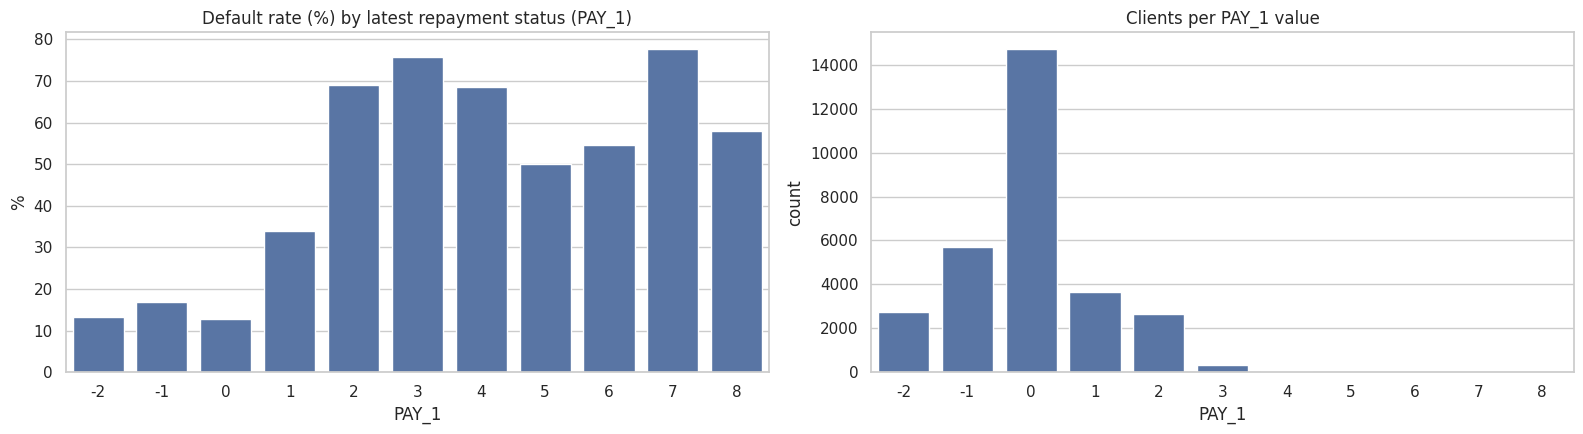

,default_rate_%,count
PAY_1,,
-2,13.2,2750
-1,16.8,5682
0,12.8,14737
1,34.0,3667
2,69.1,2666
3,75.8,322
4,68.4,76
5,50.0,26
6,54.5,11


In [14]:
# The key relationship: repayment status vs default
fig, axes = plt.subplots(1,2, figsize=(16,4.5))
rate = df.groupby("PAY_1")["default"].agg(["mean","count"])
sns.barplot(x=rate.index, y=rate["mean"]*100, ax=axes[0]); axes[0].set_title("Default rate (%) by latest repayment status (PAY_1)")
axes[0].set_ylabel("%")
sns.countplot(x="PAY_1", data=df, ax=axes[1]); axes[1].set_title("Clients per PAY_1 value")
savefig("06_pay1_vs_default"); plt.show()
rate.assign(mean=(rate["mean"]*100).round(1)).rename(columns={"mean":"default_rate_%"})

In [15]:
# Chi-square tests: is each categorical variable statistically associated with default?
for c in cat_cols:
    chi2,p,_,_ = stats.chi2_contingency(pd.crosstab(df[c], df["default"]))
    print(f"{c:10s} chi2={chi2:8.1f}  p-value={p:.2e}")

SEX        chi2=    47.1  p-value=6.64e-12
EDUCATION  chi2=   160.5  p-value=1.46e-34
MARRIAGE   chi2=    27.5  p-value=1.07e-06


### Multivariate analysis

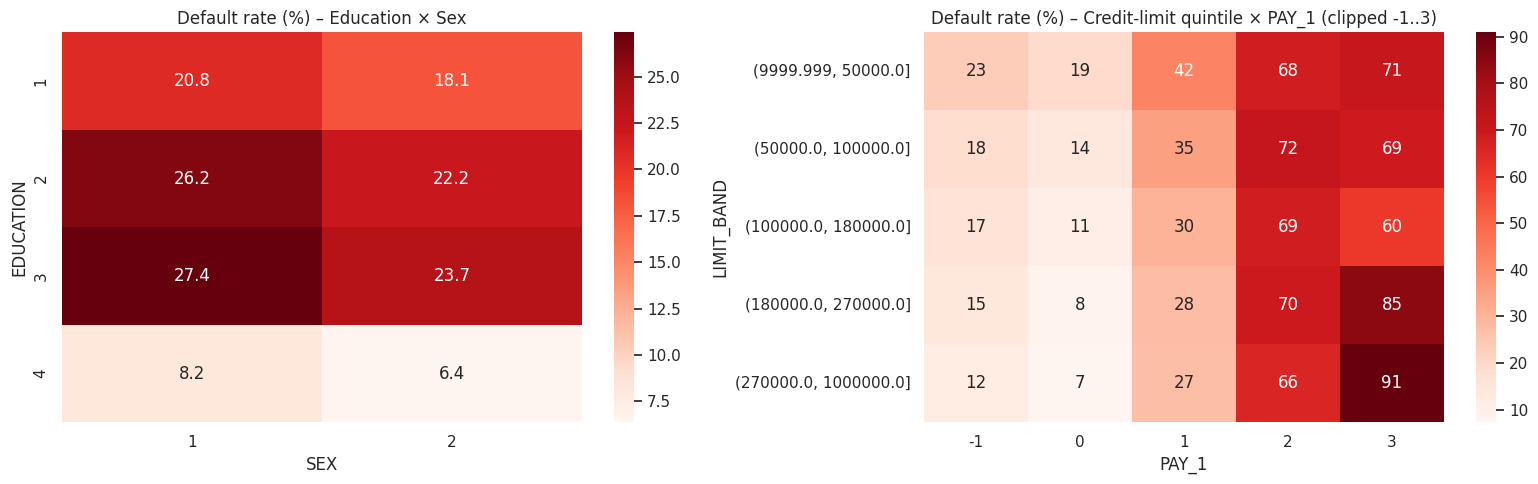

In [16]:
fig, axes = plt.subplots(1,2, figsize=(16,5))
pv = df.pivot_table(index="EDUCATION", columns="SEX", values="default", aggfunc="mean")*100
sns.heatmap(pv, annot=True, fmt=".1f", cmap="Reds", ax=axes[0]); axes[0].set_title("Default rate (%) – Education × Sex")
df["LIMIT_BAND"] = pd.qcut(df["LIMIT_BAL"], 5)
pv2 = df.pivot_table(index="LIMIT_BAND", columns=df["PAY_1"].clip(-1,3), values="default", aggfunc="mean")*100
sns.heatmap(pv2, annot=True, fmt=".0f", cmap="Reds", ax=axes[1]); axes[1].set_title("Default rate (%) – Credit-limit quintile × PAY_1 (clipped -1..3)")
savefig("07_multivariate"); plt.show()

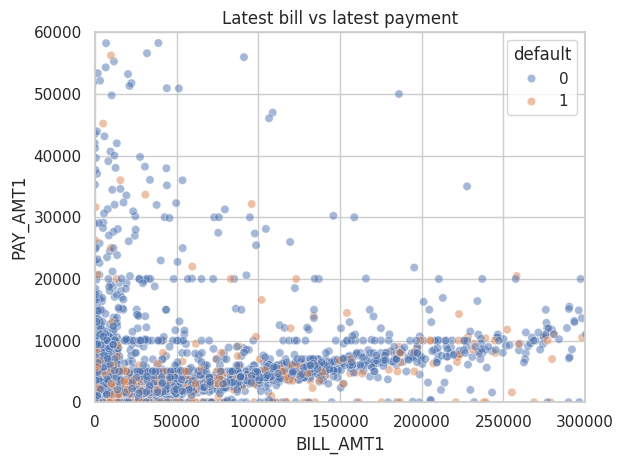

In [17]:
sns.scatterplot(data=df.sample(4000, random_state=RANDOM_STATE), x="BILL_AMT1", y="PAY_AMT1", hue="default", alpha=.5)
plt.xlim(0,300000); plt.ylim(0,60000); plt.title("Latest bill vs latest payment")
savefig("08_scatter_bill_payment"); plt.show()
df = df.drop(columns=["AGE_BAND","LIMIT_BAND"])

**EDA insights (verify against the plots when you run it)**
1. Default rate climbs steeply with the latest repayment delay: clients 2+ months late in September default at several times the rate of clients who paid duly.
2. Lower credit limits are associated with higher default rates.
3. Demographic effects (sex, marital status, education, age) exist but are small compared with payment behaviour; they should also not be used for lending decisions on fairness grounds (see Limitations).
4. Defaulters typically pay a much smaller fraction of their bill each month.

# D. Data Preprocessing
- Duplicates, undocumented category codes: handled above.
- No missing values.
- **Encoding:** `SEX`, `EDUCATION`, `MARRIAGE` are nominal → one-hot. `PAY_x` are ordered codes → kept numeric.
- **Outliers:** bills/payments are skewed but are *real* financial values, not errors, so rows are not deleted. Tree models are insensitive to them; for linear/KNN models we apply a `log1p` style signed transform + scaling.
- **Scaling:** needed for Logistic Regression and KNN (inside a `Pipeline`, fitted on training data only to avoid leakage).
- **Split:** stratified 80/20 so both sets keep the 22% default rate.

# E. Feature Engineering
| Feature | Why it should help |
|---|---|
| `AVG_BILL`, `AVG_PAY_AMT` | Smooth out month-to-month noise in six bill/payment columns |
| `PAY_RATIO_k = PAY_AMT_k / BILL_AMT_(k)` (+ `AVG_PAY_RATIO`) | Share of the bill actually repaid – more informative than raw amounts |
| `UTILIZATION_k = BILL_AMT_k / LIMIT_BAL` (+ `AVG_UTILIZATION`) | High credit utilisation is a classic credit-risk signal |
| `MAX_DELAY`, `N_MONTHS_DELAYED`, `AVG_PAY_STATUS` | Summarise 6-month delinquency history |
| `RECENT_DELAY_TREND = PAY_1 − PAY_6` | Is behaviour getting worse or better? |
| `BILL_TREND = BILL_AMT1 − BILL_AMT6` | Is the balance growing? |

**Timing note:** `PAY_AMT_k` is the payment made in the month *k*, which clears the bill of month *k+1* (older). So ratio `k` uses `PAY_AMT_k / BILL_AMT_(k+1)` for k = 1…5.

In [18]:
def engineer(d):
    d = d.copy()
    bills = [f"BILL_AMT{i}" for i in range(1,7)]
    pays  = [f"PAY_AMT{i}"  for i in range(1,7)]
    d["AVG_BILL"]    = d[bills].mean(axis=1)
    d["AVG_PAY_AMT"] = d[pays].mean(axis=1)
    for k in range(1,6):                       # payment in month k pays the previous month's bill (k+1)
        denom = d[f"BILL_AMT{k+1}"].where(d[f"BILL_AMT{k+1}"] > 0)
        d[f"PAY_RATIO_{k}"] = (d[f"PAY_AMT{k}"] / denom).clip(0, 5).fillna(1.0)   # no balance owed -> fully paid
    d["AVG_PAY_RATIO"] = d[[f"PAY_RATIO_{k}" for k in range(1,6)]].mean(axis=1)
    for k in range(1,7):
        d[f"UTIL_{k}"] = (d[f"BILL_AMT{k}"] / d["LIMIT_BAL"]).clip(-1, 3)
    d["AVG_UTILIZATION"] = d[[f"UTIL_{k}" for k in range(1,7)]].mean(axis=1)
    d["MAX_DELAY"]        = d[pay_cols].max(axis=1)
    d["N_MONTHS_DELAYED"] = (d[pay_cols] > 0).sum(axis=1)
    d["AVG_PAY_STATUS"]   = d[pay_cols].mean(axis=1)
    d["RECENT_DELAY_TREND"] = d["PAY_1"] - d["PAY_6"]
    d["BILL_TREND"] = d["BILL_AMT1"] - d["BILL_AMT6"]
    return d

df_fe = engineer(df)
new_feats = [c for c in df_fe.columns if c not in df.columns]
print(len(new_feats), "new features")
df_fe[new_feats + ["default"]].corr()["default"].drop("default").sort_values(key=abs, ascending=False).round(3).head(10)

20 new features


N_MONTHS_DELAYED      0.398
MAX_DELAY             0.331
AVG_PAY_STATUS        0.282
RECENT_DELAY_TREND    0.129
UTIL_6                0.124
UTIL_5                0.120
UTIL_4                0.117
AVG_UTILIZATION       0.116
UTIL_3                0.106
AVG_PAY_RATIO        -0.104
Name: default, dtype: float64

In [19]:
# Build model matrix: one-hot encode nominal columns, drop ID/target, stratified split
X = pd.get_dummies(df_fe.drop(columns=["ID","default"]), columns=cat_cols, drop_first=True, dtype=int)
y = df_fe["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape, "| default rate train/test:", y_train.mean().round(3), y_test.mean().round(3))

# For scale-sensitive models: signed log transform of money columns, then standardise
money_cols = [c for c in X.columns if c.startswith(("BILL_AMT","PAY_AMT")) or c in ["LIMIT_BAL","AVG_BILL","AVG_PAY_AMT","BILL_TREND"]]
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
slog = FunctionTransformer(lambda a: np.sign(a)*np.log1p(np.abs(a)))
def scaled(model):
    ct = ColumnTransformer([("money", Pipeline([("log", slog), ("sc", StandardScaler())]), money_cols)],
                           remainder=StandardScaler())
    return Pipeline([("prep", ct), ("clf", model)])

(23972, 46) (5993, 46) | default rate train/test: 0.221 0.221


# F. Model Development
We compare five models. Because only ~22% of clients default, we use `class_weight="balanced"` where the algorithm supports it (Logistic Regression, Decision Tree, Random Forest). AdaBoost and KNN are trained as-is (no class-weight option), so their recall at the default 0.5 threshold will be low — the threshold analysis later addresses this for every model.

In [20]:
models = {
    "Logistic Regression": scaled(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "AdaBoost":            AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE),
    "KNN":                 scaled(KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1)),
}

def metrics(model, X_, y_):
    pred = model.predict(X_); proba = model.predict_proba(X_)[:,1]
    return dict(Accuracy=accuracy_score(y_,pred), Precision=precision_score(y_,pred, zero_division=0),
                Recall=recall_score(y_,pred), F1=f1_score(y_,pred), ROC_AUC=roc_auc_score(y_,proba))

rows=[]
for name, m in models.items():
    m.fit(X_train, y_train)
    tr, te = metrics(m, X_train, y_train), metrics(m, X_test, y_test)
    rows.append({"Model":name, **{f"Train {k}":v for k,v in tr.items()}, **{f"Test {k}":v for k,v in te.items()}})
results = pd.DataFrame(rows).set_index("Model")
results.round(3)

,Train Accuracy,Train Precision,Train Recall,Train F1,Train ROC_AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC_AUC
Model,,,,,,,,,,
Logistic Regression,0.755,0.461,0.628,0.532,0.772,0.746,0.446,0.606,0.514,0.758
Decision Tree,0.755,0.462,0.662,0.545,0.788,0.737,0.433,0.621,0.510,0.758
Random Forest,0.927,0.786,0.921,0.848,0.975,0.798,0.549,0.496,0.521,0.772
AdaBoost,0.820,0.695,0.334,0.452,0.787,0.817,0.685,0.317,0.433,0.771
KNN,0.999,1.000,0.998,0.999,1.000,0.809,0.629,0.339,0.440,0.756


In [21]:
# 5-fold stratified CV on the training set -> more reliable than a single split
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
cv_rows=[]
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=["accuracy","recall","f1","roc_auc"], n_jobs=-1)
    cv_rows.append({"Model":name, **{k: f"{s['test_'+k].mean():.3f} ± {s['test_'+k].std():.3f}" for k in ["accuracy","recall","f1","roc_auc"]}})
pd.DataFrame(cv_rows).set_index("Model")

,accuracy,recall,f1,roc_auc
Model,,,,
Logistic Regression,0.755 ± 0.005,0.627 ± 0.014,0.531 ± 0.010,0.768 ± 0.010
Decision Tree,0.756 ± 0.008,0.626 ± 0.025,0.532 ± 0.008,0.773 ± 0.005
Random Forest,0.806 ± 0.006,0.521 ± 0.013,0.542 ± 0.012,0.783 ± 0.008
AdaBoost,0.818 ± 0.003,0.329 ± 0.009,0.444 ± 0.009,0.781 ± 0.010
KNN,0.809 ± 0.003,0.332 ± 0.009,0.435 ± 0.010,0.759 ± 0.010


In [22]:
# Overfitting check: train vs test gap
gap = pd.DataFrame({"Train F1": results["Train F1"], "Test F1": results["Test F1"],
                    "Train AUC": results["Train ROC_AUC"], "Test AUC": results["Test ROC_AUC"]})
gap["AUC gap"] = gap["Train AUC"] - gap["Test AUC"]
gap.round(3).sort_values("AUC gap", ascending=False)

,Train F1,Test F1,Train AUC,Test AUC,AUC gap
Model,,,,,
KNN,0.999,0.440,1.000,0.756,0.244
Random Forest,0.848,0.521,0.975,0.772,0.204
Decision Tree,0.545,0.510,0.788,0.758,0.030
AdaBoost,0.452,0.433,0.787,0.771,0.016
Logistic Regression,0.532,0.514,0.772,0.758,0.013


| Model | Strengths | Weaknesses |
|---|---|---|
| Logistic Regression | Fast, interpretable coefficients, regulator-friendly | Linear; can't capture interactions |
| Decision Tree | Human-readable rules | Unstable, overfits if deep |
| Random Forest | Captures non-linearity/interactions, robust to outliers | Less transparent, larger |
| AdaBoost | Strong on tabular data, few knobs | No class weights → low recall at 0.5 threshold |
| KNN | No training, simple | Slow at scoring, hurt by noisy/irrelevant features, no interpretability |

# G. Model Evaluation
**Which metric matters?** A missed defaulter (False Negative) means the bank loses the principal; a false alarm (False Positive) means a good customer is declined or priced higher – a smaller loss. So we prioritise **Recall** on the default class, while watching **Precision** (to avoid rejecting too many good customers) and **ROC-AUC / PR-AUC** (ranking quality independent of threshold). Accuracy alone is misleading with a 78/22 split.

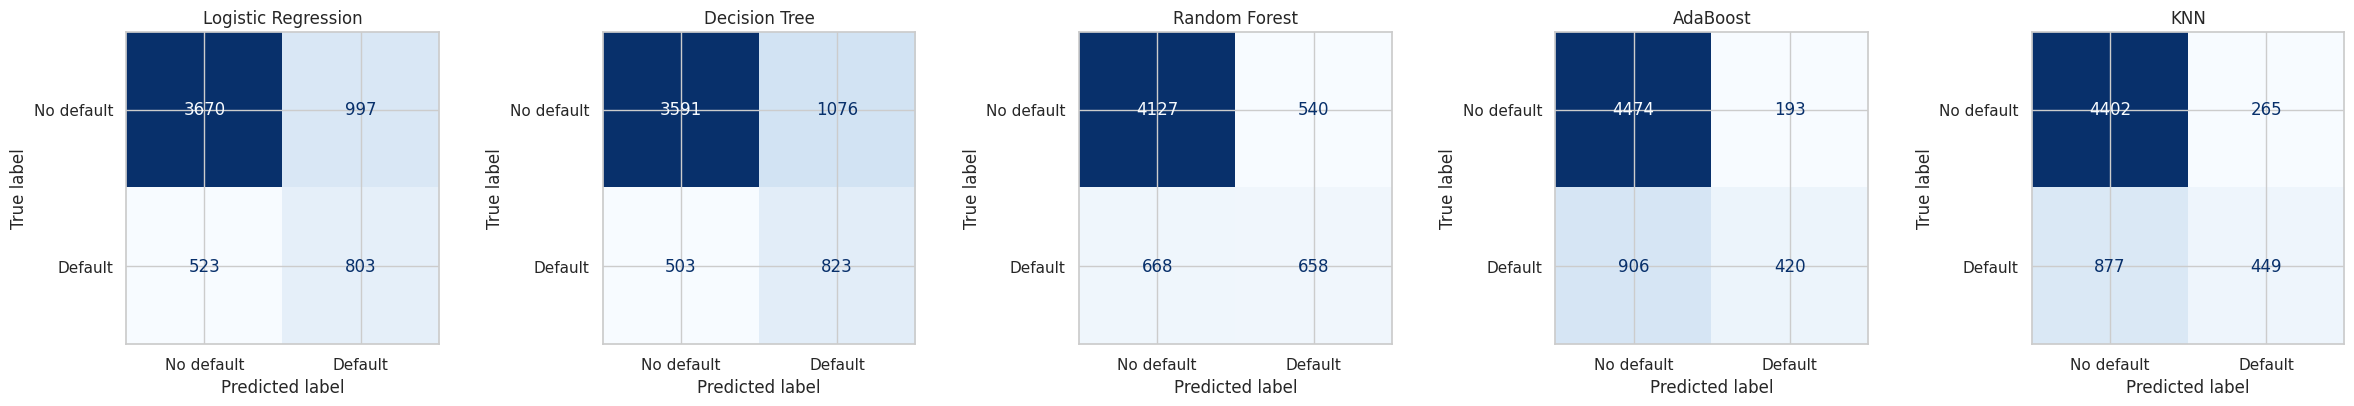

In [23]:
fig, axes = plt.subplots(1,5, figsize=(24,4.2))
for ax,(name,m) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, display_labels=["No default","Default"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
savefig("09_confusion_matrices"); plt.show()

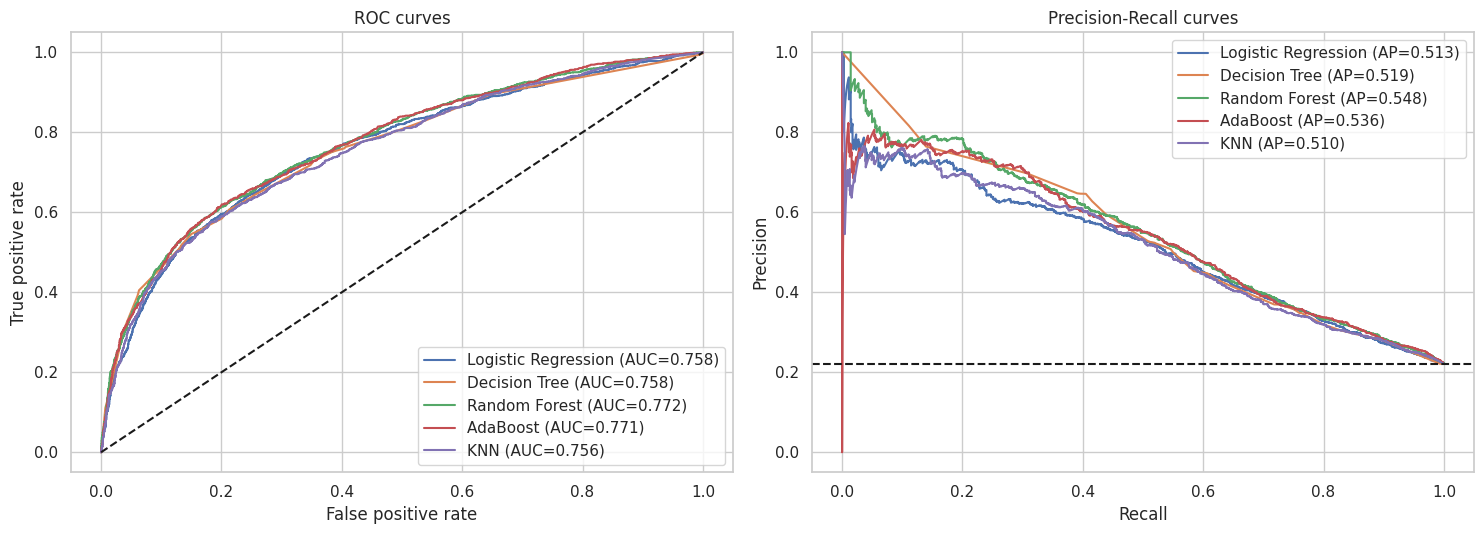

In [24]:
fig, axes = plt.subplots(1,2, figsize=(15,5.5))
for name,m in models.items():
    p = m.predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test,p);  axes[0].plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(y_test,p):.3f})")
    pr,rc,_ = precision_recall_curve(y_test,p); axes[1].plot(rc,pr,label=f"{name} (AP={average_precision_score(y_test,p):.3f})")
axes[0].plot([0,1],[0,1],"k--"); axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curves"); axes[0].legend()
axes[1].axhline(y_test.mean(), color="k", ls="--"); axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curves"); axes[1].legend()
savefig("10_roc_pr_curves"); plt.show()

### Hyperparameter tuning (Random Forest and Logistic Regression), scored on recall-aware F1

In [25]:
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    {"n_estimators":[200,400], "max_depth":[6,10,None], "min_samples_leaf":[5,20]},
    scoring="roc_auc", cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_, "| CV AUC:", round(rf_grid.best_score_,4))

lr_grid = GridSearchCV(scaled(LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
                       {"clf__C":[0.01,0.1,1,10]}, scoring="roc_auc", cv=3, n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("Best LR params:", lr_grid.best_params_, "| CV AUC:", round(lr_grid.best_score_,4))

tuned = {"Random Forest (tuned)": rf_grid.best_estimator_, "Logistic Regression (tuned)": lr_grid.best_estimator_}
tuned_res = pd.DataFrame({n: metrics(m, X_test, y_test) for n,m in tuned.items()}).T
tuned_res.round(3)

Best RF params: {'max_depth': 10, 'min_samples_leaf': 20, 'n_estimators': 200} | CV AUC: 0.7884
Best LR params: {'clf__C': 0.01} | CV AUC: 0.7678


,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest (tuned),0.775,0.493,0.601,0.542,0.777
Logistic Regression (tuned),0.746,0.445,0.607,0.514,0.759


### Decision-threshold tuning
The default 0.5 cut-off is arbitrary. A bank can choose the threshold according to the relative cost of a missed defaulter vs. a rejected good customer. Below, we assume a missed defaulter costs **5×** a false alarm (an assumption – replace it with the bank's real cost ratio).

Cost-minimising threshold (validation): 0.35


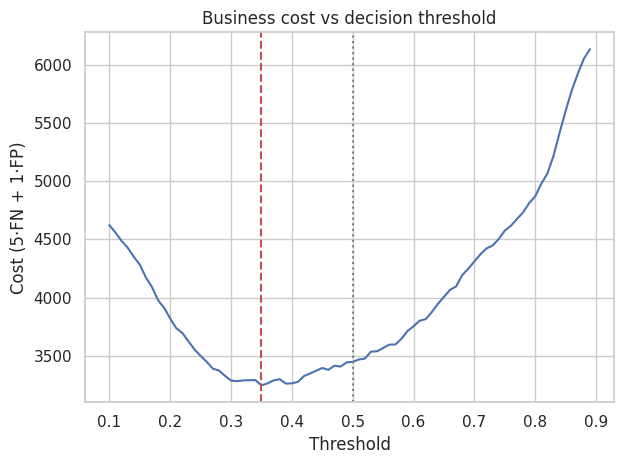

In [26]:
COST_FN, COST_FP = 5, 1          # ASSUMPTION: relative cost of missing a defaulter vs. a false alarm
final_name  = "Random Forest (tuned)"
final_model = tuned[final_name]

# Choose the threshold on a validation split carved out of TRAIN (never on test) -> no leakage
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE)
from sklearn.base import clone
val_model = clone(final_model).fit(X_tr, y_tr)
pv = val_model.predict_proba(X_val)[:,1]
ths = np.arange(0.1, 0.9, 0.01)
cost = []
for t in ths:
    tn,fp,fn,tp = confusion_matrix(y_val, pv>=t).ravel()
    cost.append(COST_FN*fn + COST_FP*fp)
best_t = ths[int(np.argmin(cost))]
print(f"Cost-minimising threshold (validation): {best_t:.2f}")
plt.plot(ths, cost); plt.axvline(best_t, color="r", ls="--"); plt.axvline(0.5, color="gray", ls=":")
plt.xlabel("Threshold"); plt.ylabel(f"Cost ({COST_FN}·FN + {COST_FP}·FP)"); plt.title("Business cost vs decision threshold")
savefig("11_threshold_cost"); plt.show()

In [27]:
final_model.fit(X_train, y_train)         # already fitted by GridSearch on full train; refit is harmless
p_test = final_model.predict_proba(X_test)[:,1]
rows={}
for label,t in [("Default threshold 0.50",0.5), (f"Cost-optimised {best_t:.2f}",best_t)]:
    pred=(p_test>=t).astype(int); tn,fp,fn,tp=confusion_matrix(y_test,pred).ravel()
    rows[label]=dict(Accuracy=accuracy_score(y_test,pred), Precision=precision_score(y_test,pred), Recall=recall_score(y_test,pred),
                     F1=f1_score(y_test,pred), FN=fn, FP=fp, Cost=COST_FN*fn+COST_FP*fp)
final_report = pd.DataFrame(rows).T
final_report.round(3)

,Accuracy,Precision,Recall,F1,FN,FP,Cost
Default threshold 0.50,0.775,0.493,0.601,0.542,529.0,818.0,3463.0
Cost-optimised 0.35,0.630,0.349,0.780,0.483,292.0,1926.0,3386.0


              precision    recall  f1-score   support

  No default       0.90      0.59      0.71      4667
     Default       0.35      0.78      0.48      1326

    accuracy                           0.63      5993
   macro avg       0.63      0.68      0.60      5993
weighted avg       0.78      0.63      0.66      5993



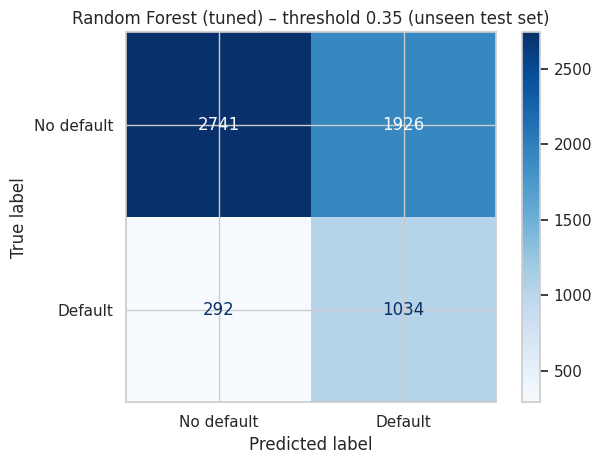

In [28]:
pred_final = (p_test>=best_t).astype(int)
print(classification_report(y_test, pred_final, target_names=["No default","Default"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred_final, display_labels=["No default","Default"], cmap="Blues")
plt.title(f"{final_name} – threshold {best_t:.2f} (unseen test set)"); savefig("12_final_confusion"); plt.show()

# 6. Validating the Results
Checks performed: five-model comparison, confusion matrices, train-vs-test gap, 5-fold CV stability, a final hold-out test used **once** for the chosen model/threshold.
Below: calibration (are predicted probabilities trustworthy?) and an importance analysis.

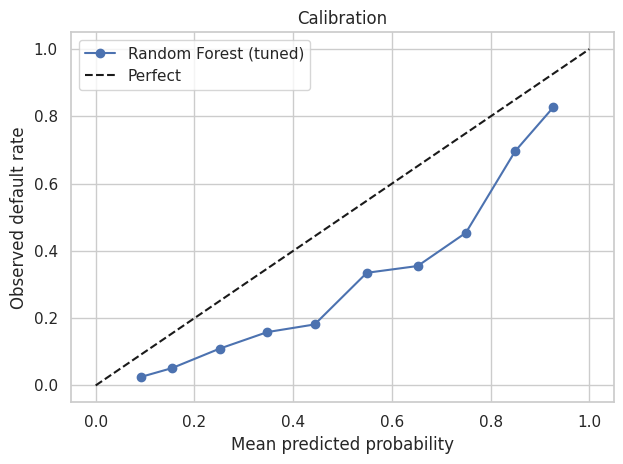

In [29]:
from sklearn.calibration import calibration_curve
frac, mean_pred = calibration_curve(y_test, p_test, n_bins=10)
plt.plot(mean_pred, frac, "o-", label=final_name); plt.plot([0,1],[0,1],"k--", label="Perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed default rate"); plt.legend(); plt.title("Calibration")
savefig("13_calibration"); plt.show()

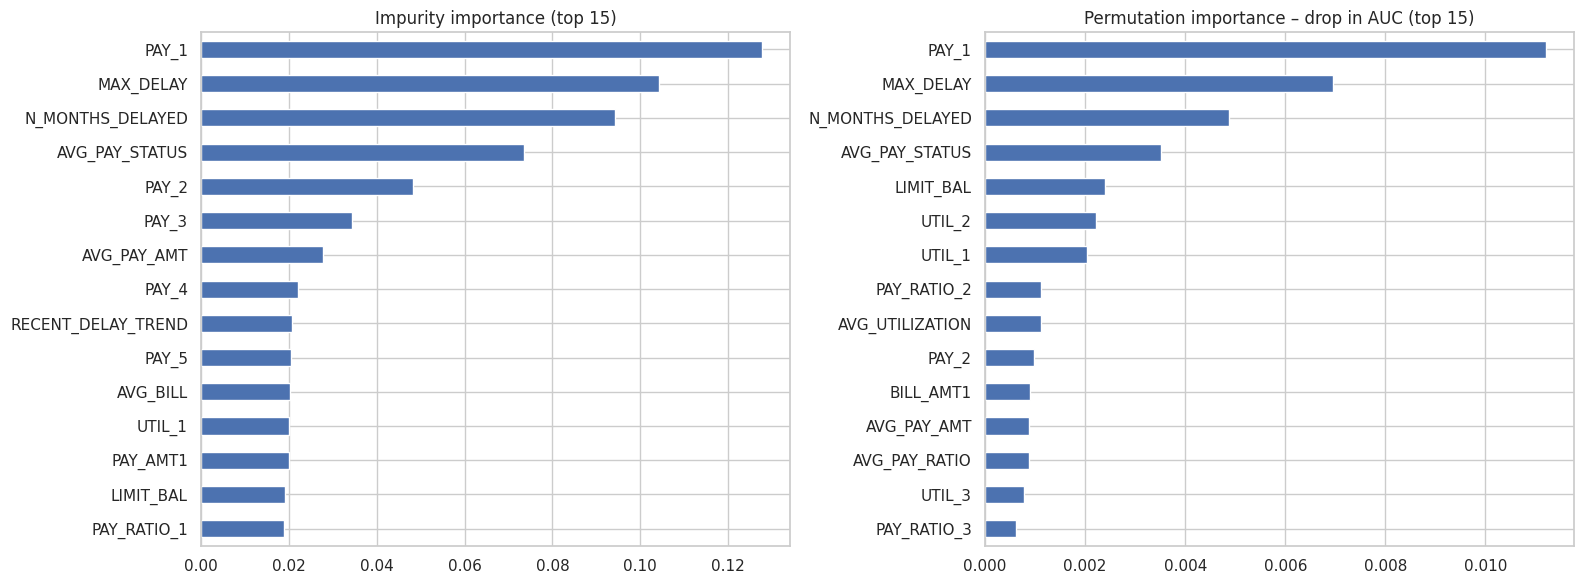

In [30]:
# Feature importance: impurity-based AND permutation (permutation is less biased toward high-cardinality features)
imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1,2, figsize=(16,6))
imp.head(15)[::-1].plot(kind="barh", ax=axes[0], title="Impurity importance (top 15)")
perm_s.head(15)[::-1].plot(kind="barh", ax=axes[1], title="Permutation importance – drop in AUC (top 15)")
savefig("14_feature_importance"); plt.show()

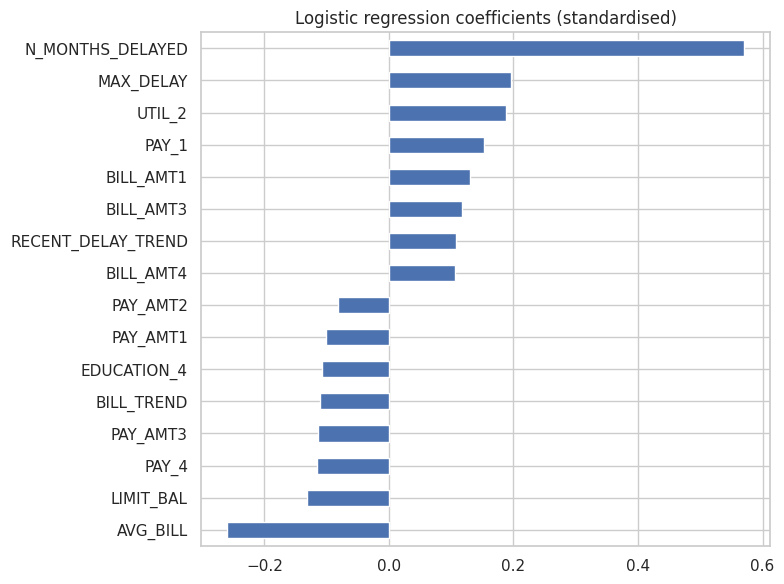

In [31]:
# Interpretable view: logistic-regression coefficients (direction of effect)
lr = lr_grid.best_estimator_.named_steps["clf"]
names = money_cols + [c for c in X.columns if c not in money_cols]   # ColumnTransformer output order
coef = pd.Series(lr.coef_[0], index=names).sort_values()
pd.concat([coef.head(8), coef.tail(8)]).plot(kind="barh", figsize=(8,6), title="Logistic regression coefficients (standardised)")
savefig("15_lr_coefficients"); plt.show()

## "If you were a Data Scientist in a bank, why would you trust this model?"
Fill in with your own numbers after running – but the argument should cover:
1. **Generalisation:** train vs test and CV scores are close (small AUC gap); the test set was touched once.
2. **Business-aligned metric:** the model/threshold was chosen to minimise misclassification *cost*, not to maximise accuracy; recall on defaulters is much better than the naive baseline.
3. **Sensible drivers:** the most important features are repayment delay, utilisation and payment ratio – what credit officers already believe – not spurious variables.
4. **Calibration:** predicted probabilities roughly match observed default rates, so they can feed pricing.
5. **Caveats – I would NOT let it decide alone:** use it as a risk score with human review for borderline cases, monitor drift, and re-train regularly.

# 7. Business Insights & Recommendations

In [32]:
# Segment risk: where is default concentrated?
seg = X_test.copy(); seg["default"] = y_test.values; seg["risk_score"] = p_test
seg["PAY_1_band"] = pd.cut(seg["PAY_1"], [-3,-1,0,1,9], labels=["Paid duly","Revolving","1 month late","2+ months late"])
seg["Limit_band"] = pd.qcut(seg["LIMIT_BAL"], 4, labels=["Q1 lowest","Q2","Q3","Q4 highest"])
seg["Util_band"]  = pd.cut(seg["AVG_UTILIZATION"], [-2,0.3,0.6,0.9,5], labels=["<30%","30-60%","60-90%",">90%"])
for col in ["PAY_1_band","Limit_band","Util_band"]:
    t = seg.groupby(col, observed=True).agg(clients=("default","size"), actual_default_rate=("default","mean"), avg_predicted_risk=("risk_score","mean")).round(3)
    display(t)

,clients,actual_default_rate,avg_predicted_risk
PAY_1_band,,,
Paid duly,1737,0.151,0.338
Revolving,2917,0.136,0.299
1 month late,718,0.334,0.600
2+ months late,621,0.688,0.844


,clients,actual_default_rate,avg_predicted_risk
Limit_band,,,
Q1 lowest,1510,0.311,0.528
Q2,1538,0.259,0.426
Q3,1505,0.161,0.350
Q4 highest,1440,0.149,0.302


,clients,actual_default_rate,avg_predicted_risk
Util_band,,,
<30%,3081,0.174,0.364
30-60%,1074,0.234,0.385
60-90%,1280,0.274,0.454
>90%,558,0.337,0.533


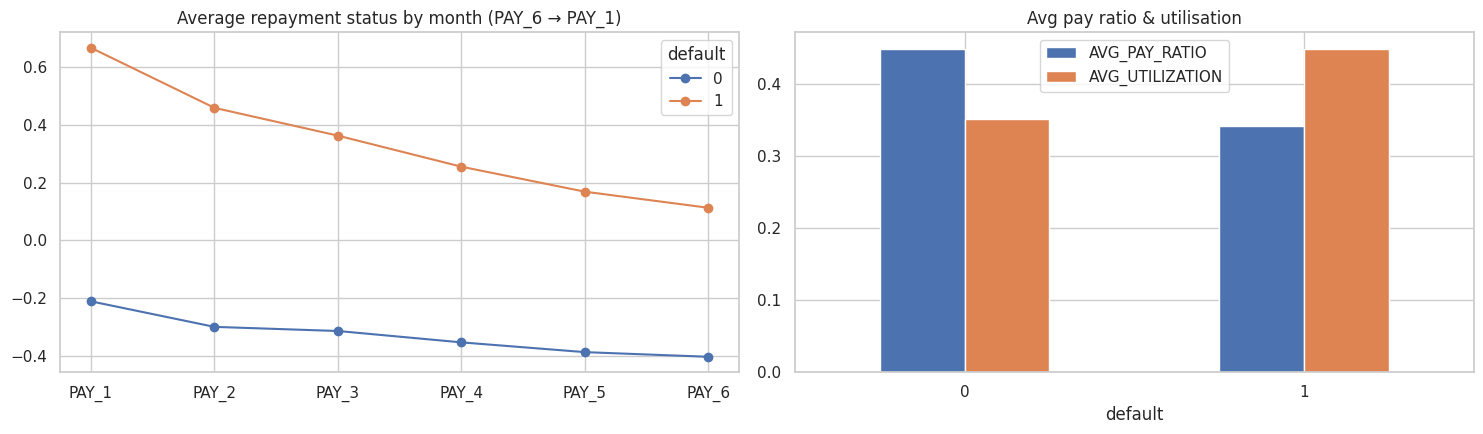

In [33]:
# Repayment pattern of defaulters vs non-defaulters
fig, axes = plt.subplots(1,2, figsize=(15,4.5))
df.groupby("default")[pay_cols].mean().T.plot(ax=axes[0], marker="o", title="Average repayment status by month (PAY_6 → PAY_1)")
axes[0].invert_xaxis() if False else None
df_fe.groupby("default")[["AVG_PAY_RATIO","AVG_UTILIZATION"]].mean().plot(kind="bar", ax=axes[1], rot=0, title="Avg pay ratio & utilisation")
savefig("16_defaulter_patterns"); plt.show()

### Answers to the business questions (confirm numbers from the tables above)
- **Who defaults more?** Clients already delaying payment in the latest cycle, with high credit utilisation, low repayment ratio, and lower credit limits.
- **Strongest financial factors:** latest repayment status (`PAY_1`) and delinquency history (`MAX_DELAY`, `N_MONTHS_DELAYED`), then utilisation and payment ratio.
- **Highest-risk segments:** "2+ months late" and ">90% utilisation" clients.
- **Defaulter pattern:** delays persist and worsen over consecutive months; they pay only a small part of each bill.

### Recommendations
1. **Early-warning system:** flag any client with a payment delay in the latest cycle and contact them within days (reminders, restructuring) – the biggest single risk lever.
2. **Risk-based limits & pricing:** cap limit increases for clients with high utilisation or falling pay-ratio; price risk using the model's calibrated probability.
3. **Collections prioritisation:** rank accounts by predicted risk × exposure (bill amount) so collectors work the highest expected-loss accounts first.
4. **Product nudges:** auto-debit / minimum-payment reminders and instalment plans for clients who repeatedly pay only the minimum.
5. **Use a cost-based threshold,** agreed with Risk/Finance, rather than 0.5; review it every quarter.
6. **Governance:** do not use sex, marital status or age directly in decisions (fair-lending law/ethics); monitor drift and fairness across groups.

# Limitations
- Single-country, single-period (2005 Taiwan) credit-card data; behaviour and the economy change → needs re-validation before use elsewhere.
- Only the 6-month history is available: no income, employment, or bureau score; and the target is a single next-month event.
- The cost ratio (5:1) is an assumption.
- Demographic variables are in the data; using them could be discriminatory – recommend excluding them in production (try the model without them to see the AUC cost).
- Sampling bias: we only see clients who were *already approved*.
- Not addressed: SMOTE/undersampling (class weights used instead), gradient boosting/XGBoost, SHAP – good extensions.

In [34]:
# Save the final model and predictions
import joblib
os.makedirs("../models", exist_ok=True)
joblib.dump({"model": final_model, "threshold": best_t, "columns": list(X.columns)}, "../models/final_model.joblib")
out = X_test.copy(); out["actual_default"]=y_test.values; out["default_probability"]=p_test.round(4); out["predicted_default"]=pred_final
out[["actual_default","default_probability","predicted_default"]].to_csv("../reports/test_predictions.csv", index=True)
results.round(4).to_csv("../reports/model_comparison.csv")
print("Saved model, predictions and comparison table.")

Saved model, predictions and comparison table.
